<a href="https://colab.research.google.com/github/arnav-is-op/Major_project_Predictive_Quantification_of_Health_and_Happiness/blob/main/major_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving world_happiness_report.csv to world_happiness_report.csv


{'world_happiness_report.csv': b'Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,Education_Index,Population,Urbanization_Rate,Life_Satisfaction,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate\nChina,2022,4.39,44984.68,0.53,71.11,0.41,-0.05,0.83,14.98,0.52,1311940760,78.71,8.88,0.34,76.44,46.06,8.92,62.75,8.59,74.4,70.3,0.29,61.38\nUK,2015,5.49,30814.59,0.93,63.14,0.89,0.04,0.84,19.46,0.83,1194240877,50.87,5.03,0.72,53.38,46.43,4.43,53.11,8.76,91.74,73.32,0.76,80.18\nBrazil,2009,4.65,39214.84,0.03,62.36,0.01,0.16,0.59,16.68,0.95,731100898,48.75,5.22,0.23,82.4,31.03,3.78,33.3,6.06,71.8,28.99,0.94,72.65\nFrance,2019,5.2,30655.75,0.77,78.94,0.98,0.25,0.63,2.64,0.7,1293957314,81.78,5.69,0.68,46.87,57.65,4.43,90.59,6.36,86.16,45.76,0.48,55.14\nChina,2022,7.28,30016.87,0.05,50.3

In [4]:
!pip install numpy pandas matplotlib scikit-learn statsmodels tensorflow

Loaded: world_happiness_report.csv
Shape: (4000, 24)
Columns: ['Country', 'Year', 'Happiness_Score', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Generosity', 'Corruption_Perception', 'Unemployment_Rate', 'Education_Index', 'Population', 'Urbanization_Rate', 'Life_Satisfaction', 'Public_Trust', 'Mental_Health_Index', 'Income_Inequality', 'Public_Health_Expenditure', 'Climate_Index', 'Work_Life_Balance', 'Internet_Access', 'Crime_Rate', 'Political_Stability', 'Employment_Rate']
Duplicates found (Country,Year): 3800 -> aggregating by mean

After preprocessing:
Shape: (200, 24)
Missing values (top 10 columns):
Country                    0.0
Year                       0.0
Happiness_Score            0.0
GDP_per_Capita             0.0
Social_Support             0.0
Healthy_Life_Expectancy    0.0
Freedom                    0.0
Generosity                 0.0
Corruption_Perception      0.0
Unemployment_Rate          0.0
dtype: float64

Feature engineering added col

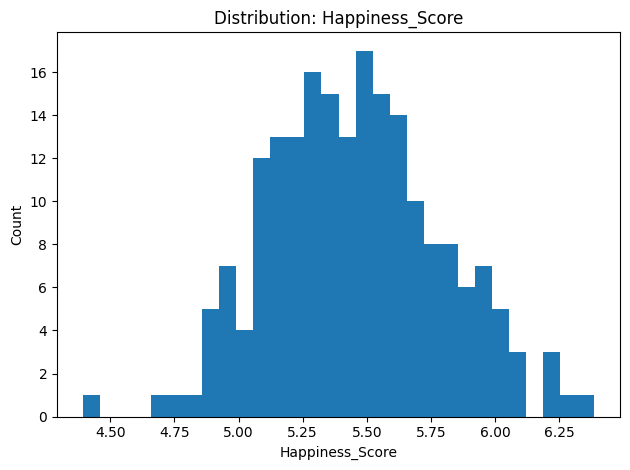

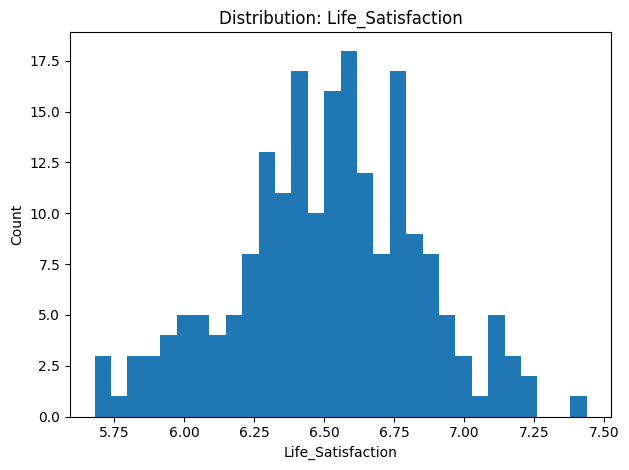

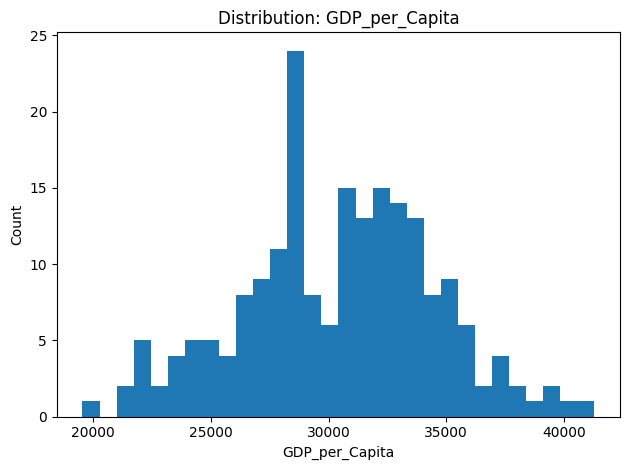

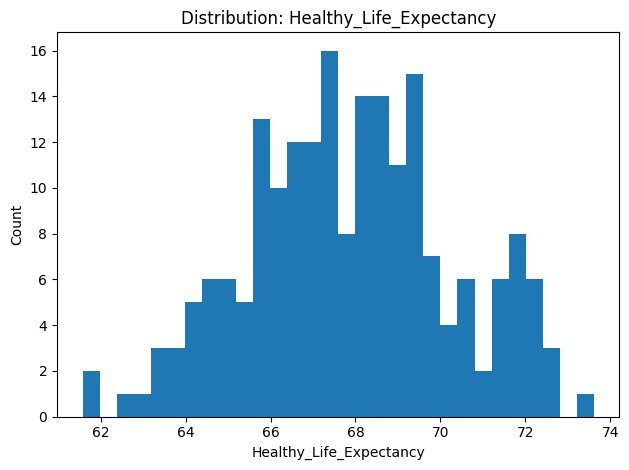

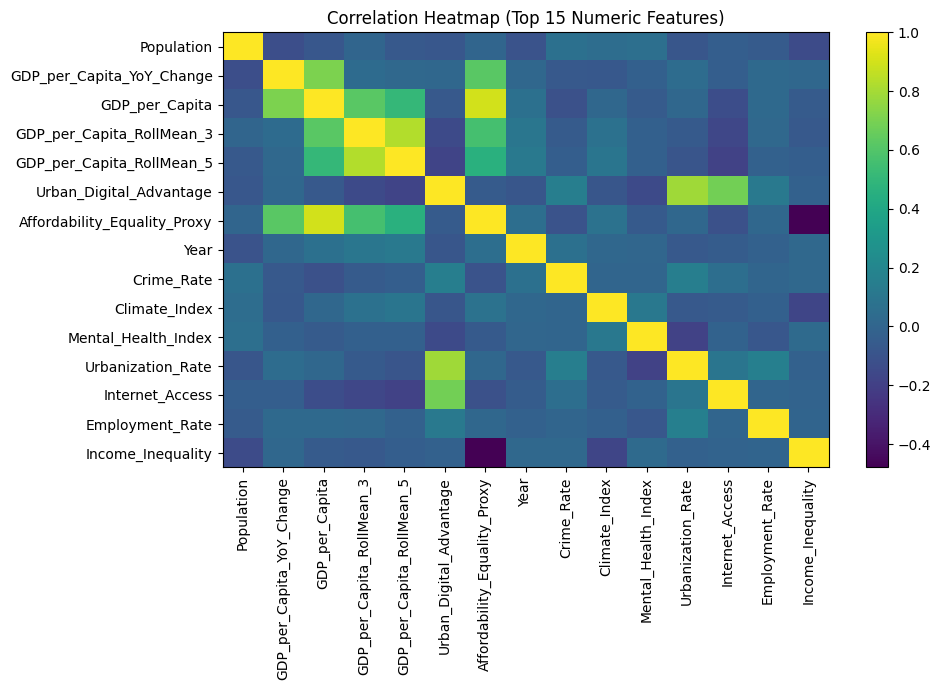

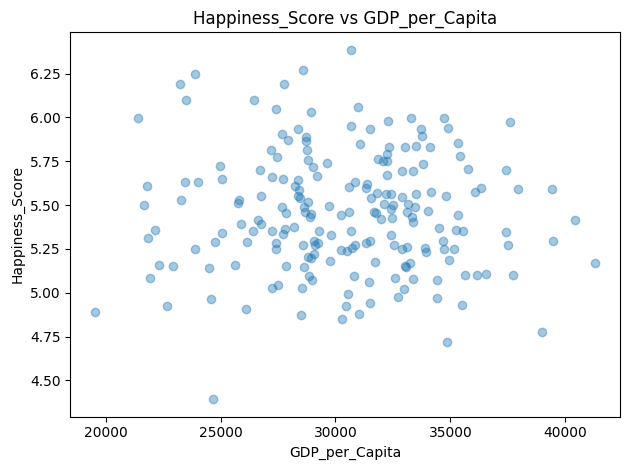

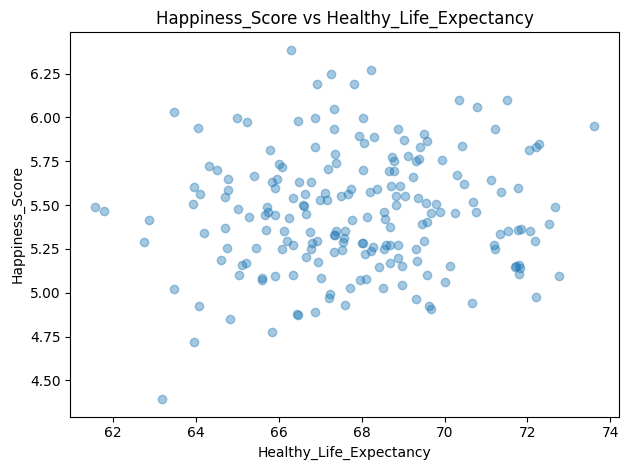

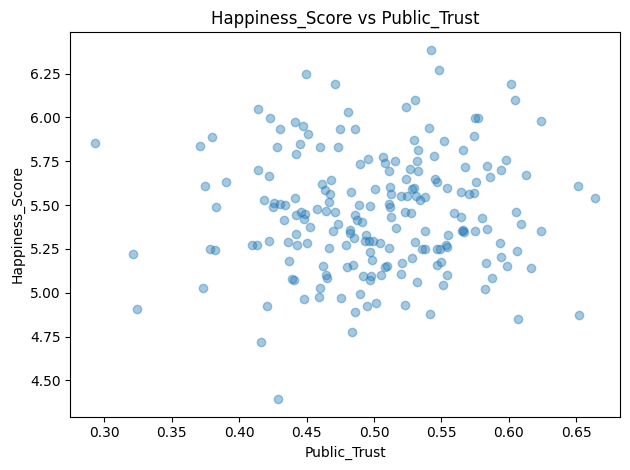

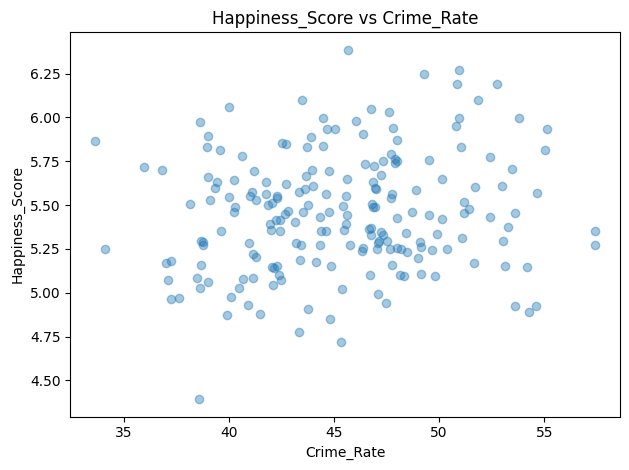

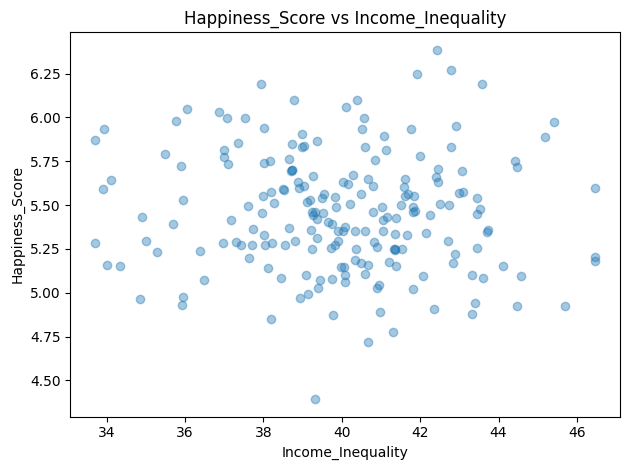

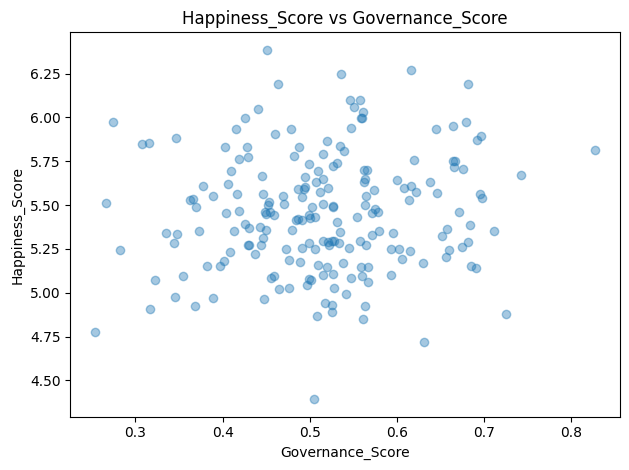


Top 10 countries by Happiness_Score in 2024:
     Country  Happiness_Score
      France         6.045789
   Australia         5.836522
       India         5.600000
South Africa         5.475625
      Canada         5.390000
       China         5.296364
          UK         5.281429
      Brazil         5.251905
     Germany         5.100455
         USA         5.072857

Bottom 10 countries by Happiness_Score in 2024:
     Country  Happiness_Score
         USA         5.072857
     Germany         5.100455
      Brazil         5.251905
          UK         5.281429
       China         5.296364
      Canada         5.390000
South Africa         5.475625
       India         5.600000
   Australia         5.836522
      France         6.045789


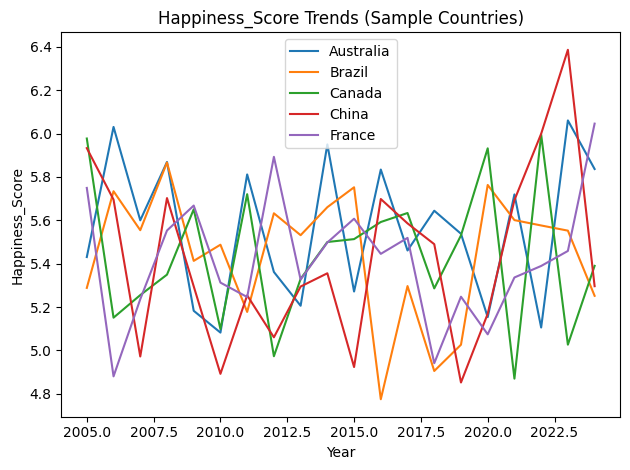


Saved: country_profiles_latest_year.csv

Country encoding: one-hot (small number of countries)

--- Regression Models: Predict Happiness_Score ---
Time-aware split year threshold: 2020
Train size: (160, 43) Test size: (40, 43)

Saved: model_comparison_regression.csv

Model Comparison (Regression):
         Model      MAE     RMSE       R2
Lasso (scaled) 0.127669 0.162366 0.800674
  RandomForest 0.151987 0.193499 0.716906
Saved: predictions_test_regression.csv


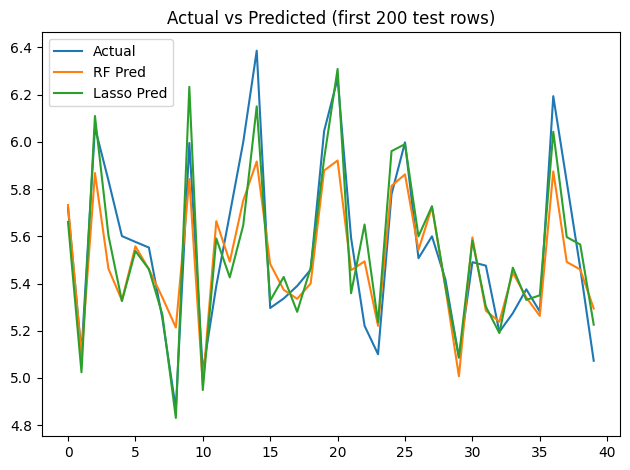

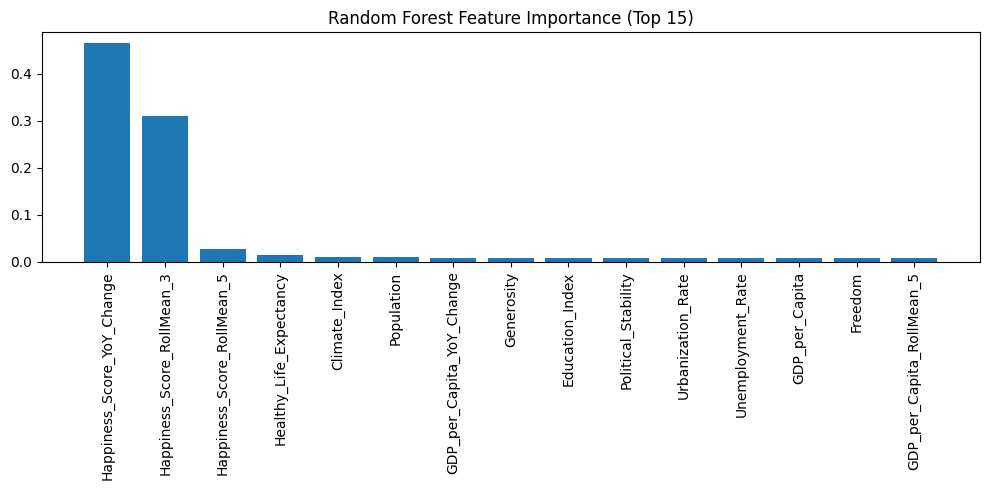


--- Classification: Predict Happiness_Tier ---
Accuracy: 0.75   Macro-F1: 0.7036

Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.69      0.78        13
         Low       1.00      0.38      0.55         8
      Medium       0.67      0.95      0.78        19

    accuracy                           0.75        40
   macro avg       0.86      0.67      0.70        40
weighted avg       0.81      0.75      0.74        40

Saved: tier_predictions_test.csv

--- Clustering (KMeans + DBSCAN) ---
Saved: cluster_profiles_kmeans.csv


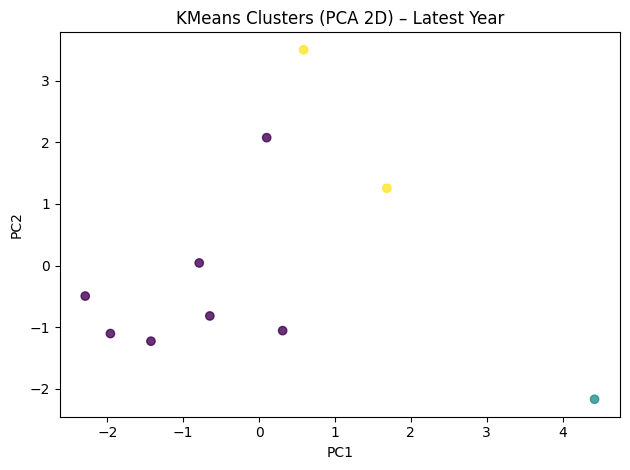


Sample countries per KMeans cluster:

Cluster 0
     Country  Happiness_Score  Life_Satisfaction
South Africa         5.475625           6.366875
      Canada         5.390000           6.689474
       China         5.296364           6.596364
          UK         5.281429           6.741905
      Brazil         5.251905           6.748571

Cluster 1
Country  Happiness_Score  Life_Satisfaction
 France         6.045789           7.227895

Cluster 2
  Country  Happiness_Score  Life_Satisfaction
Australia         5.836522           6.580870
    India         5.600000           6.585714

--- Forecasting (ARIMA + LSTM) ---
Note: Forecasting requires a meaningful time-series length per country or global aggregate.

ARIMA(1,1,1) on Global Mean Happiness_Score
MAE: 0.1141   RMSE: 0.1329


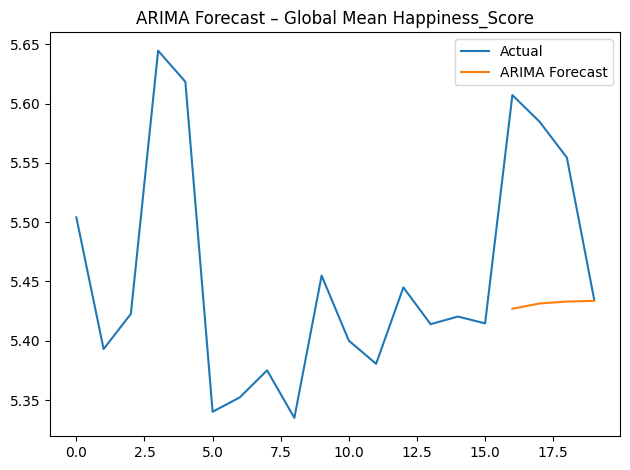


LSTM Forecast on Global Mean Happiness_Score
MAE: 0.1105   RMSE: 0.1252


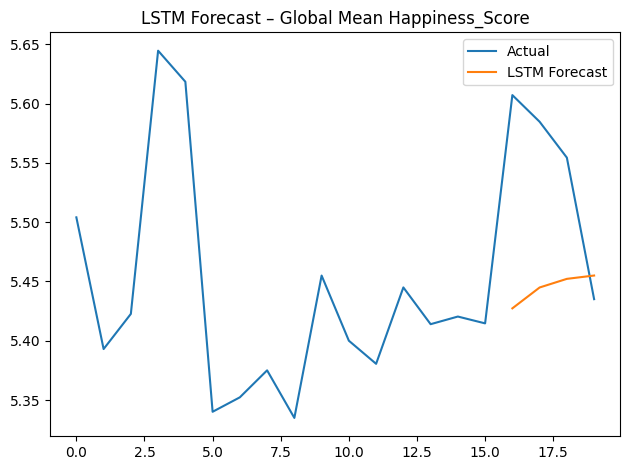

In [15]:
"""
Predictive Quantification of Health and Happiness
--------------------------------------------------
Dataset: world_happiness_report.csv
"""

# ── Install optional dependencies (run this cell first in Colab) ──────────────
# !pip install statsmodels tensorflow -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

# ARIMA (statsmodels) – optional
try:
    from statsmodels.tsa.arima.model import ARIMA
    HAS_ARIMA = True
except Exception:
    HAS_ARIMA = False

# LSTM (TensorFlow / Keras) – optional
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    HAS_TF = True
except Exception:
    HAS_TF = False

# ── Load Data ──────────────────────────────────────────────────────────────────
CSV_PATH = "world_happiness_report.csv"   # <-- make sure this file is uploaded
df = pd.read_csv(CSV_PATH)

print("Loaded:", CSV_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

# ── Preprocessing ──────────────────────────────────────────────────────────────

# 1.1 Validate / convert Year to integer
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Convert all non-identifier numeric columns to numeric (coerce errors)
id_cols = ["Country", "Year"]
for col in df.columns:
    if col in id_cols:
        continue
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows where Country is missing (hard identifier)
df["Country"] = df["Country"].astype(str)
df = df[df["Country"].str.strip().ne("")].copy()

# Sort (Country, Year) for time-series-friendly operations
df = df.sort_values(["Country", "Year"]).reset_index(drop=True)

# Remove duplicates: if duplicates exist for (Country, Year), aggregate by mean
dup_count = df.duplicated(subset=["Country", "Year"]).sum()
if dup_count > 0:
    print("Duplicates found (Country,Year):", int(dup_count), "-> aggregating by mean")
    num_cols = [c for c in df.columns if c not in ["Country", "Year"]]
    df = df.groupby(["Country", "Year"], as_index=False)[num_cols].mean()

# Handle missing values
# Strategy:
# - Within each country over time: forward fill then backward fill
# - Any remaining: fill numeric with median
num_cols = [c for c in df.columns if c not in ["Country", "Year"]]
df[num_cols] = df.groupby("Country")[num_cols].ffill()
df[num_cols] = df.groupby("Country")[num_cols].bfill()

medians = df[num_cols].median(numeric_only=True)
df[num_cols] = df[num_cols].fillna(medians)

# Remove rows with missing Year after conversion (if any)
df = df[df["Year"].notna()].copy()
df["Year"] = df["Year"].astype(int)

# 1.8 Outlier treatment: IQR capping (Winsorization-like)
def cap_outliers_iqr(s, k=1.5):
    """Cap outliers using IQR bounds. Keeps NaN as-is."""
    s = s.copy()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return s
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return s.clip(lo, hi)

outlier_cols = [c for c in ["GDP_per_Capita", "Crime_Rate", "Population",
                             "Unemployment_Rate", "Income_Inequality"]
                if c in df.columns]
for c in outlier_cols:
    df[c] = cap_outliers_iqr(df[c], k=1.5)

# Light capping for all numeric cols (helps stabilize models)
for c in num_cols:
    df[c] = cap_outliers_iqr(df[c], k=2.0)

print("\nAfter preprocessing:")
print("Shape:", df.shape)
print("Missing values (top 10 columns):")
print(df.isna().mean().sort_values(ascending=False).head(10))

# ── Feature Engineering ────────────────────────────────────────────────────────
eps = 1e-9

def minmax_norm(series):
    mn = series.min()
    mx = series.max()
    if mx - mn == 0:
        return series * 0
    return (series - mn) / (mx - mn)

# Health-Wealth Composite
cols_hwc = [c for c in ["GDP_per_Capita", "Healthy_Life_Expectancy",
                         "Public_Health_Expenditure"] if c in df.columns]
if len(cols_hwc) >= 2:
    tmp = sum(minmax_norm(df[c]) for c in cols_hwc)
    df["Health_Wealth_Composite"] = tmp / len(cols_hwc)
else:
    df["Health_Wealth_Composite"] = np.nan

# Governance Score
gov_parts = []
if "Political_Stability" in df.columns:
    gov_parts.append(minmax_norm(df["Political_Stability"]))
if "Public_Trust" in df.columns:
    gov_parts.append(minmax_norm(df["Public_Trust"]))
if "Corruption_Perception" in df.columns:
    gov_parts.append(1 - minmax_norm(df["Corruption_Perception"]))
if len(gov_parts) > 0:
    df["Governance_Score"] = np.mean(np.vstack(gov_parts), axis=0)
else:
    df["Governance_Score"] = np.nan

# Safety Score
safety_parts = []
if "Crime_Rate" in df.columns:
    safety_parts.append(1 - minmax_norm(df["Crime_Rate"]))
if "Political_Stability" in df.columns:
    safety_parts.append(minmax_norm(df["Political_Stability"]))
df["Safety_Score"] = (np.mean(np.vstack(safety_parts), axis=0)
                      if len(safety_parts) else np.nan)

# Affordability / Equality proxy
if "GDP_per_Capita" in df.columns and "Income_Inequality" in df.columns:
    df["Affordability_Equality_Proxy"] = (df["GDP_per_Capita"] /
                                          (df["Income_Inequality"] + eps))
else:
    df["Affordability_Equality_Proxy"] = np.nan

# Urban-digital advantage
if "Urbanization_Rate" in df.columns and "Internet_Access" in df.columns:
    df["Urban_Digital_Advantage"] = df["Urbanization_Rate"] * df["Internet_Access"]
else:
    df["Urban_Digital_Advantage"] = np.nan

# Year-over-Year changes and rolling means
for base_col in ["Happiness_Score", "GDP_per_Capita"]:
    if base_col in df.columns:
        df[f"{base_col}_YoY_Change"] = df.groupby("Country")[base_col].diff()
        df[f"{base_col}_RollMean_3"] = (df.groupby("Country")[base_col]
                                        .rolling(window=3, min_periods=1)
                                        .mean().reset_index(level=0, drop=True))
        df[f"{base_col}_RollMean_5"] = (df.groupby("Country")[base_col]
                                        .rolling(window=5, min_periods=1)
                                        .mean().reset_index(level=0, drop=True))

# Fill engineered NaNs from diff with 0 (first year for each country)
eng_cols = [c for c in df.columns if c not in ["Country", "Year"]]
df[eng_cols] = df[eng_cols].fillna(0)

# Happiness tiers (High / Medium / Low) based on quartiles
if "Happiness_Score" in df.columns:
    q1 = df["Happiness_Score"].quantile(0.25)
    q3 = df["Happiness_Score"].quantile(0.75)

    def tier(x):
        if x <= q1:
            return "Low"
        if x >= q3:
            return "High"
        return "Medium"

    df["Happiness_Tier"] = df["Happiness_Score"].apply(tier)
else:
    df["Happiness_Tier"] = "Unknown"

print("\nFeature engineering added columns (examples):")
print([c for c in df.columns if c not in ["Country", "Year"]][:20])

# ── EDA (Exploratory Data Analysis) ───────────────────────────────────────────
print("\n--- EDA ---")

# Missingness analysis
missing_pct = df.isna().mean().sort_values(ascending=False)
print("\nMissingness % (top 10):")
print((missing_pct * 100).head(10))

# Univariate distributions
key_cols = [c for c in ["Happiness_Score", "Life_Satisfaction",
                         "GDP_per_Capita", "Healthy_Life_Expectancy",
                         "Crime_Rate", "Income_Inequality"] if c in df.columns]
for c in key_cols[:4]:
    plt.figure()
    plt.hist(df[c].astype(float), bins=30)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Correlation heatmap (top 15 numeric features by variance)
num_only = (df.drop(columns=["Country", "Happiness_Tier"])
            .select_dtypes(include=[np.number]).copy())
variances = num_only.var()
top_num_cols = list(variances.sort_values(ascending=False).head(15).index)
corr = num_only[top_num_cols].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr.values, aspect="auto")
plt.xticks(range(len(top_num_cols)), top_num_cols, rotation=90)
plt.yticks(range(len(top_num_cols)), top_num_cols)
plt.title("Correlation Heatmap (Top 15 Numeric Features)")
plt.colorbar()
plt.tight_layout()
plt.show()

# Scatter plots: Happiness vs drivers
drivers = [c for c in ["GDP_per_Capita", "Healthy_Life_Expectancy",
                        "Public_Trust", "Crime_Rate", "Income_Inequality",
                        "Governance_Score", "Health_Wealth_Composite"]
           if c in df.columns]
if "Happiness_Score" in df.columns:
    for c in drivers[:6]:
        plt.figure()
        plt.scatter(df[c], df["Happiness_Score"], alpha=0.4)
        plt.title(f"Happiness_Score vs {c}")
        plt.xlabel(c)
        plt.ylabel("Happiness_Score")
        plt.tight_layout()
        plt.show()

# Country ranking per year (top / bottom 10)
if "Happiness_Score" in df.columns:
    last_year = int(df["Year"].max())
    yr = df[df["Year"] == last_year].copy()
    top10  = yr.sort_values("Happiness_Score", ascending=False).head(10)[["Country", "Happiness_Score"]]
    bot10  = yr.sort_values("Happiness_Score", ascending=True ).head(10)[["Country", "Happiness_Score"]]
    print(f"\nTop 10 countries by Happiness_Score in {last_year}:")
    print(top10.to_string(index=False))
    print(f"\nBottom 10 countries by Happiness_Score in {last_year}:")
    print(bot10.to_string(index=False))

# Trend analysis: sample countries
selected_countries = list(df["Country"].dropna().unique()[:5])
if "Happiness_Score" in df.columns and len(selected_countries) > 0:
    plt.figure()
    for ctry in selected_countries:
        sub = df[df["Country"] == ctry].sort_values("Year")
        plt.plot(sub["Year"], sub["Happiness_Score"], label=ctry)
    plt.title("Happiness_Score Trends (Sample Countries)")
    plt.xlabel("Year")
    plt.ylabel("Happiness_Score")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ── Country Profiles (Latest Year) ────────────────────────────────────────────
latest_year = int(df["Year"].max())
latest = df[df["Year"] == latest_year].copy()

profile_cols = ["Country", "Year"]
for c in ["Happiness_Score", "Life_Satisfaction", "Health_Wealth_Composite",
          "Governance_Score", "Safety_Score"]:
    if c in latest.columns:
        profile_cols.append(c)

country_profiles = (latest[profile_cols].sort_values(profile_cols[2], ascending=False)
                    if len(profile_cols) > 2 else latest[profile_cols])
country_profiles.to_csv("country_profiles_latest_year.csv", index=False)
print("\nSaved: country_profiles_latest_year.csv")

# ── Encoding Country ───────────────────────────────────────────────────────────
country_counts = df["Country"].value_counts()
df["Country_FreqEnc"] = df["Country"].map(country_counts).astype(float)

USE_ONE_HOT_COUNTRY = (df["Country"].nunique() <= 30)

if USE_ONE_HOT_COUNTRY:
    df_onehot = pd.get_dummies(df["Country"], prefix="CTRY", drop_first=True)
    df_model = pd.concat([df.drop(columns=["Country"]), df_onehot], axis=1)
    print("\nCountry encoding: one-hot (small number of countries)")
else:
    df_model = df.drop(columns=["Country"]).copy()
    print("\nCountry encoding: frequency encoding (many countries)")

# ── Regression: Predict Happiness_Score (Lasso vs Random Forest) ──────────────
print("\n--- Regression Models: Predict Happiness_Score ---")

TARGET_COL = "Happiness_Score"
if TARGET_COL not in df_model.columns:
    print("Happiness_Score not present. Skipping regression.")
else:
    y = pd.to_numeric(df_model[TARGET_COL], errors="coerce")
    X = df_model.drop(columns=[TARGET_COL, "Happiness_Tier"], errors="ignore").copy()

    # Remove rows where y is invalid
    mask = y.notna() & np.isfinite(y)
    X = X.loc[mask].copy()
    y = y.loc[mask].copy()

    # Time-aware split: train on earlier years, test on later years
    years = df.loc[mask, "Year"].astype(int)
    split_year = int(np.quantile(years.unique(), 0.8))
    train_idx = years <= split_year
    test_idx  = years  > split_year

    X_train, y_train = X.loc[train_idx], y.loc[train_idx]
    X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

    print("Time-aware split year threshold:", split_year)
    print("Train size:", X_train.shape, "Test size:", X_test.shape)

    # Scale for Lasso
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Lasso Regression
    lasso = Lasso(alpha=0.001, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    pred_lasso = lasso.predict(X_test_scaled)

    # Random Forest Regression
    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    def reg_metrics(y_true, y_pred):
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)
        return mae, rmse, r2

    mae_l, rmse_l, r2_l = reg_metrics(y_test, pred_lasso)
    mae_r, rmse_r, r2_r = reg_metrics(y_test, pred_rf)

    cmp = pd.DataFrame([
        {"Model": "Lasso (scaled)", "MAE": mae_l, "RMSE": rmse_l, "R2": r2_l},
        {"Model": "RandomForest",   "MAE": mae_r, "RMSE": rmse_r, "R2": r2_r},
    ]).sort_values("RMSE")

    cmp.to_csv("model_comparison_regression.csv", index=False)
    print("\nSaved: model_comparison_regression.csv")
    print("\nModel Comparison (Regression):")
    print(cmp.to_string(index=False))

    # Save test predictions
    pred_out = X_test.copy()
    pred_out["y_true"]     = y_test.values
    pred_out["pred_lasso"] = pred_lasso
    pred_out["pred_rf"]    = pred_rf
    pred_out["Year"]       = years.loc[test_idx].values
    pred_out.to_csv("predictions_test_regression.csv", index=False)
    print("Saved: predictions_test_regression.csv")

    # Visual: actual vs predicted
    plt.figure()
    plt.plot(y_test.values[:200],   label="Actual")
    plt.plot(pred_rf[:200],         label="RF Pred")
    plt.plot(pred_lasso[:200],      label="Lasso Pred")
    plt.title("Actual vs Predicted (first 200 test rows)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Feature importance (top 15)
    importances = (pd.Series(rf.feature_importances_, index=X_train.columns)
                   .sort_values(ascending=False).head(15))
    plt.figure(figsize=(10, 5))
    plt.bar(importances.index, importances.values)
    plt.title("Random Forest Feature Importance (Top 15)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# ── Classification: Predict Happiness Tier (High / Medium / Low) ──────────────
print("\n--- Classification: Predict Happiness_Tier ---")

if "Happiness_Tier" not in df_model.columns:
    print("Happiness_Tier not present. Skipping classification.")
else:
    clf_df = df_model.copy()
    DROP_LIFE_SAT = False
    drop_cols = ["Happiness_Tier"]
    if TARGET_COL in clf_df.columns:
        drop_cols.append(TARGET_COL)
    if DROP_LIFE_SAT and "Life_Satisfaction" in clf_df.columns:
        drop_cols.append("Life_Satisfaction")

    Xc = clf_df.drop(columns=drop_cols, errors="ignore").copy()
    yc = clf_df["Happiness_Tier"].astype(str).copy()

    years_c  = df["Year"].astype(int)
    split_year_c = int(np.quantile(years_c.unique(), 0.8))
    train_idx_c = years_c <= split_year_c
    test_idx_c  = years_c  > split_year_c

    Xc_train, yc_train = Xc.loc[train_idx_c], yc.loc[train_idx_c]
    Xc_test,  yc_test  = Xc.loc[test_idx_c],  yc.loc[test_idx_c]

    scaler_c = StandardScaler()
    Xc_train_scaled = scaler_c.fit_transform(Xc_train)
    Xc_test_scaled  = scaler_c.transform(Xc_test)

    clf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
    clf.fit(Xc_train, yc_train)
    pred_tier = clf.predict(Xc_test)

    acc = accuracy_score(yc_test, pred_tier)
    flm = f1_score(yc_test, pred_tier, average="macro")

    print("Accuracy:", round(acc, 4), "  Macro-F1:", round(flm, 4))
    print("\nClassification Report:")
    print(classification_report(yc_test, pred_tier))

    tier_out = pd.DataFrame({
        "Year":   years_c.loc[test_idx_c].values,
        "y_true": yc_test.values,
        "y_pred": pred_tier
    })
    tier_out.to_csv("tier_predictions_test.csv", index=False)
    print("Saved: tier_predictions_test.csv")

# ── Clustering: KMeans + DBSCAN ────────────────────────────────────────────────
print("\n--- Clustering (KMeans + DBSCAN) ---")

cluster_df = latest.copy()
cluster_features = [c for c in [
    "Happiness_Score", "Life_Satisfaction", "Health_Wealth_Composite",
    "Governance_Score", "Safety_Score", "GDP_per_Capita",
    "Healthy_Life_Expectancy", "Public_Trust", "Crime_Rate",
    "Income_Inequality", "Internet_Access", "Education_Index", "Work_Life_Balance"
] if c in cluster_df.columns]

if len(cluster_features) < 3:
    print("Not enough features for clustering. Skipping.")
else:
    Xcl = cluster_df[cluster_features].copy()
    Xcl = Xcl.replace([np.inf, -np.inf], np.nan).fillna(Xcl.median(numeric_only=True))

    scaler_cl = StandardScaler()
    Xcl_scaled = scaler_cl.fit_transform(Xcl)

    # KMeans (k=3 to align with High/Medium/Low tiers)
    k = 3
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_df["Cluster_KMeans"] = kmeans.fit_predict(Xcl_scaled)

    # DBSCAN
    dbscan = DBSCAN(eps=0.8, min_samples=5)
    cluster_df["Cluster_DBSCAN"] = dbscan.fit_predict(Xcl_scaled)

    # Cluster profiles (means)
    profile = (cluster_df.groupby("Cluster_KMeans")[cluster_features]
               .mean(numeric_only=True).reset_index())
    profile.to_csv("cluster_profiles_kmeans.csv", index=False)
    print("Saved: cluster_profiles_kmeans.csv")

    # PCA visualization
    pca = PCA(n_components=2, random_state=42)
    X2  = pca.fit_transform(Xcl_scaled)
    plt.figure()
    plt.scatter(X2[:, 0], X2[:, 1],
                c=cluster_df["Cluster_KMeans"].values, alpha=0.8)
    plt.title("KMeans Clusters (PCA 2D) – Latest Year")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    # Sample countries per cluster
    print("\nSample countries per KMeans cluster:")
    for cl in sorted(cluster_df["Cluster_KMeans"].unique()):
        sample = (cluster_df[cluster_df["Cluster_KMeans"] == cl]
                  .sort_values("Happiness_Score", ascending=False).head(5))
        print(f"\nCluster {cl}")
        cols_to_show = [c for c in ["Country", "Happiness_Score", "Life_Satisfaction"]
                        if c in sample.columns]
        print(sample[cols_to_show].to_string(index=False))

# ── Forecasting: ARIMA + LSTM ──────────────────────────────────────────────────
print("\n--- Forecasting (ARIMA + LSTM) ---")
print("Note: Forecasting requires a meaningful time-series length per country or global aggregate.")

FORECAST_MODE    = "global"   # "global" or "country"
FORECAST_COUNTRY = df["Country"].iloc[0] if len(df) else "Unknown"
FORECAST_TARGET  = "Happiness_Score"

series_df = None
if FORECAST_TARGET in df.columns:
    if FORECAST_MODE == "global":
        series_df = (df.groupby("Year")[FORECAST_TARGET].mean()
                     .reset_index().sort_values("Year"))
        series_name = "Global Mean Happiness_Score"
    else:
        sub = df[df["Country"] == FORECAST_COUNTRY].sort_values("Year")
        series_df = sub[["Year", FORECAST_TARGET]].dropna().copy()
        series_name = f"{FORECAST_COUNTRY} Happiness_Score"
else:
    print("Forecast target not present:", FORECAST_TARGET)

if series_df is not None and len(series_df) >= 8:
    y_ts = series_df[FORECAST_TARGET].values.astype(float)

    n       = len(y_ts)
    n_train = int(n * 0.8)
    train_ts = y_ts[:n_train]
    test_ts  = y_ts[n_train:]

    # ARIMA
    if HAS_ARIMA:
        try:
            model = ARIMA(train_ts, order=(1, 1, 1))
            fit   = model.fit()
            fc    = fit.forecast(steps=len(test_ts))

            mae  = mean_absolute_error(test_ts, fc)
            rmse = np.sqrt(mean_squared_error(test_ts, fc))
            print(f"\nARIMA(1,1,1) on {series_name}")
            print("MAE:", round(mae, 4), "  RMSE:", round(rmse, 4))

            plt.figure()
            plt.plot(range(n),              y_ts, label="Actual")
            plt.plot(range(n_train, n),     fc,   label="ARIMA Forecast")
            plt.title("ARIMA Forecast – " + series_name)
            plt.legend()
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print("ARIMA failed:", e)
    else:
        print("statsmodels not available -> skipping ARIMA")

    # LSTM
    if HAS_TF:
        try:
            lookback = 3

            def make_sequences(arr, window):
                Xs, ys = [], []
                for i in range(window, len(arr)):
                    Xs.append(arr[i - window:i])
                    ys.append(arr[i])
                return np.array(Xs), np.array(ys)

            scaler_ts   = MinMaxScaler()
            train_scaled = scaler_ts.fit_transform(train_ts.reshape(-1, 1)).flatten()
            test_scaled  = scaler_ts.transform(test_ts.reshape(-1, 1)).flatten()

            X_train_s, y_train_s = make_sequences(train_scaled, lookback)
            combined = np.concatenate([train_scaled[-lookback:], test_scaled])
            X_test_s, y_test_s   = make_sequences(combined, lookback)

            X_train_s = X_train_s.reshape((X_train_s.shape[0], X_train_s.shape[1], 1))
            X_test_s  = X_test_s .reshape((X_test_s .shape[0], X_test_s .shape[1], 1))

            lstm = Sequential()
            lstm.add(LSTM(10, activation="relu", input_shape=(lookback, 1)))
            lstm.add(Dense(1))
            lstm.compile(optimizer="adam", loss="mse")
            lstm.fit(X_train_s, y_train_s, epochs=120, batch_size=8, verbose=0)

            pred_scaled = lstm.predict(X_test_s, verbose=0).flatten()
            pred = scaler_ts.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

            mae  = mean_absolute_error(test_ts, pred)
            rmse = np.sqrt(mean_squared_error(test_ts, pred))
            print(f"\nLSTM Forecast on {series_name}")
            print("MAE:", round(mae, 4), "  RMSE:", round(rmse, 4))

            plt.figure()
            plt.plot(range(n),          y_ts, label="Actual")
            plt.plot(range(n_train, n), pred, label="LSTM Forecast")
            plt.title("LSTM Forecast – " + series_name)
            plt.legend()
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print("LSTM failed:", e)
    else:
        print("TensorFlow not available -> skipping LSTM")
else:
    print("Not enough time points for forecasting (need >= 8).")